In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.feature_selection import SelectKBest, f_classif
import joblib

In [ ]:
# ── Load & Inspect Dataset ───────────────────────────────────────────────────
df = pd.read_csv("diabetes datasetba.csv")
print("Shape:", df.shape)
print(df.head())
print("\\nData Types:\\n", df.dtypes)
print("\\nMissing Values:\\n", df.isnull().sum())
print("\\nStatistical Summary:")
print(df.describe())

Shape: (10000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  30.0             0              0            ever  32.50   
1    Male  22.0             0              0         current  32.01   
2    Male  56.0             0              0           never  24.62   
3  Female  57.0             0              0            ever  27.32   
4    Male  60.0             0              0         current  29.51   

   HbA1c_level  blood_glucose_level  diabetes  
0          4.5                  130         0  
1          6.1                  140         0  
2          7.5                  240         1  
3          6.2                  155         0  
4          3.5                  100         0  
\nData Types:\n gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
dia

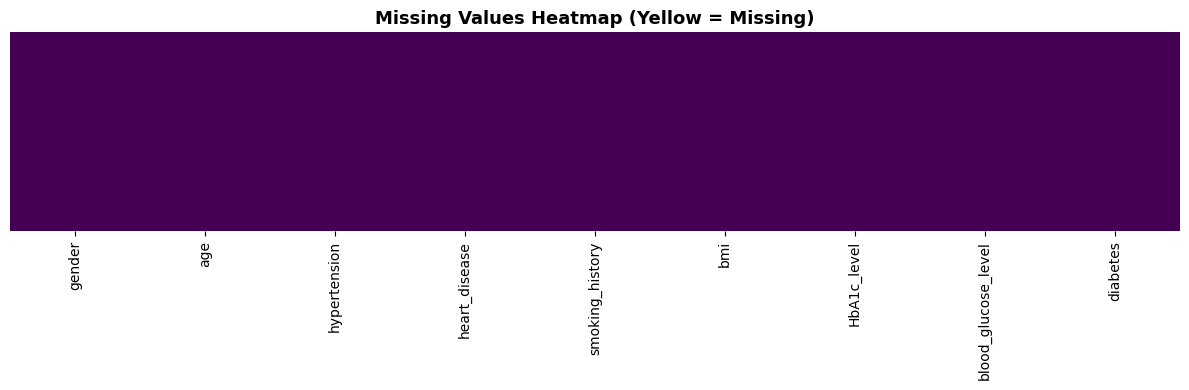

In [ ]:
# ── Missing Values Heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap (Yellow = Missing)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("missing_values_heatmap.png", dpi=150)
plt.show()

In [ ]:
# ── Preprocessing ────────────────────────────────────────────────────────────
# Drop rows where gender is 'Other' (very few, not useful)
df = df[df["gender"] != "Other"].copy()

# Encode categorical columns
le_gender  = LabelEncoder()
le_smoking = LabelEncoder()

df["gender"]          = le_gender.fit_transform(df["gender"])          # Female=0, Male=1
df["smoking_history"] = le_smoking.fit_transform(df["smoking_history"])

# Save the classes so we can use them in the Gradio app
gender_classes  = list(le_gender.classes_)    # ['Female', 'Male']
smoking_classes = list(le_smoking.classes_)   # e.g. ['No Info', 'current', 'ever', 'former', 'never', 'not current']
print("Gender classes  :", gender_classes)
print("Smoking classes :", smoking_classes)

# Handle missing values — fill numeric with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Remove outliers using IQR on numeric features
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    for col in columns:
        Q1    = df_clean[col].quantile(0.25)
        Q3    = df_clean[col].quantile(0.75)
        IQR   = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

df_clean = remove_outliers_iqr(df, numeric_cols)
print(f"\\nRows before outlier removal: {len(df)}")
print(f"Rows after  outlier removal: {len(df_clean)}")

Gender classes  : ['Female', 'Male']
Smoking classes : ['No Info', 'current', 'ever', 'former', 'never', 'not current']
\nRows before outlier removal: 9998
Rows after  outlier removal: 7707


In [ ]:
# ── Class Distribution ───────────────────────────────────────────────────────
before_counts = df["diabetes"].value_counts()
after_counts  = df_clean["diabetes"].value_counts()

print("="*50)
print("  CLASS DISTRIBUTION BEFORE OUTLIER REMOVAL")
print("="*50)
print(f"  No Diabetes (0) : {before_counts[0]}")
print(f"  Diabetes    (1) : {before_counts[1]}")
print(f"  Total           : {len(df)}")

print("\\n" + "="*50)
print("  CLASS DISTRIBUTION AFTER OUTLIER REMOVAL")
print("="*50)
print(f"  No Diabetes (0) : {after_counts[0]}")
print(f"  Diabetes    (1) : {after_counts[1]}")
print(f"  Total           : {len(df_clean)}")
print(f"\\n  Rows removed    : {len(df) - len(df_clean)}")


  CLASS DISTRIBUTION BEFORE OUTLIER REMOVAL
  No Diabetes (0) : 6498
  Diabetes    (1) : 3500
  Total           : 9998
\n==================================================
  CLASS DISTRIBUTION AFTER OUTLIER REMOVAL
  No Diabetes (0) : 6144
  Diabetes    (1) : 1563
  Total           : 7707
\n  Rows removed    : 2291


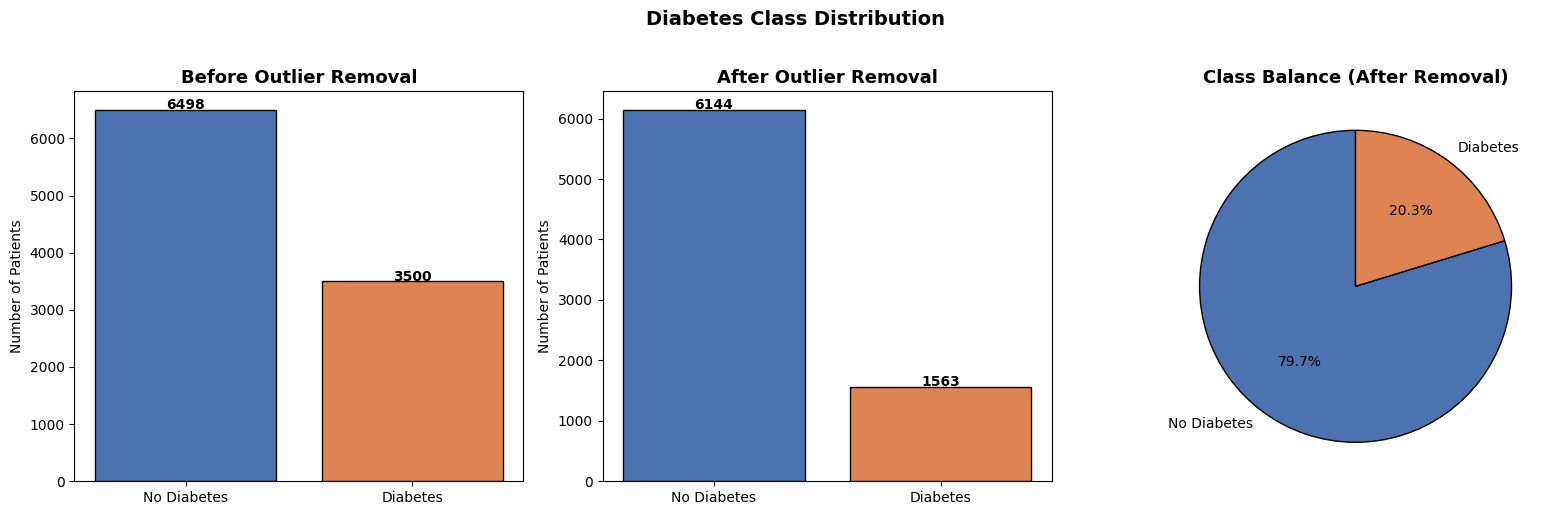

\n  No Diabetes : 79.7%
  Diabetes    : 20.3%


In [ ]:
# ── Class Distribution Charts ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ["No Diabetes", "Diabetes"]
colors = ["#4C72B0", "#DD8452"]

# Bar chart before
axes[0].bar(labels, [before_counts[0], before_counts[1]], color=colors, edgecolor="black")
axes[0].set_title("Before Outlier Removal", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Patients")
for i, v in enumerate([before_counts[0], before_counts[1]]):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Bar chart after
axes[1].bar(labels, [after_counts[0], after_counts[1]], color=colors, edgecolor="black")
axes[1].set_title("After Outlier Removal", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Patients")
for i, v in enumerate([after_counts[0], after_counts[1]]):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie chart after
total_after = len(df_clean)
axes[2].pie(
    [after_counts[0], after_counts[1]],
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black"}
)
axes[2].set_title("Class Balance (After Removal)", fontsize=13, fontweight="bold")

plt.suptitle("Diabetes Class Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

print(f"\\n  No Diabetes : {after_counts[0]/total_after*100:.1f}%")
print(f"  Diabetes    : {after_counts[1]/total_after*100:.1f}%")

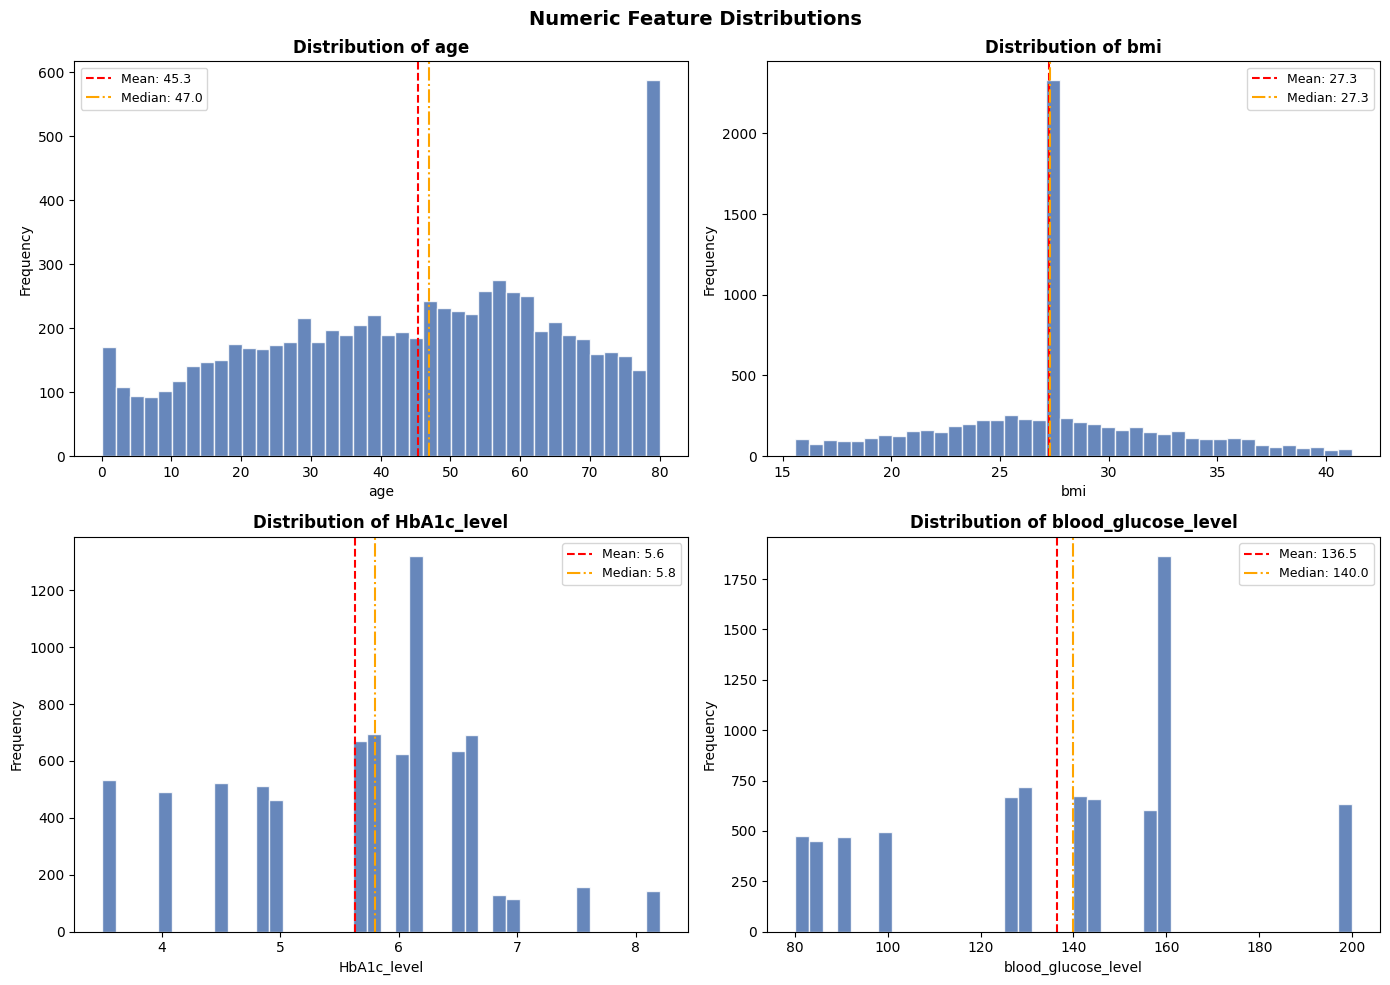

In [ ]:
# ── Numeric Feature Distributions ───────────────────────────────────────────
numeric_features = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df_clean[col], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].axvline(df_clean[col].mean(),   color="red",    linestyle="--", linewidth=1.5,
                    label=f"Mean: {df_clean[col].mean():.1f}")
    axes[i].axvline(df_clean[col].median(), color="orange", linestyle="-.", linewidth=1.5,
                    label=f"Median: {df_clean[col].median():.1f}")
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=9)

plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150)
plt.show()

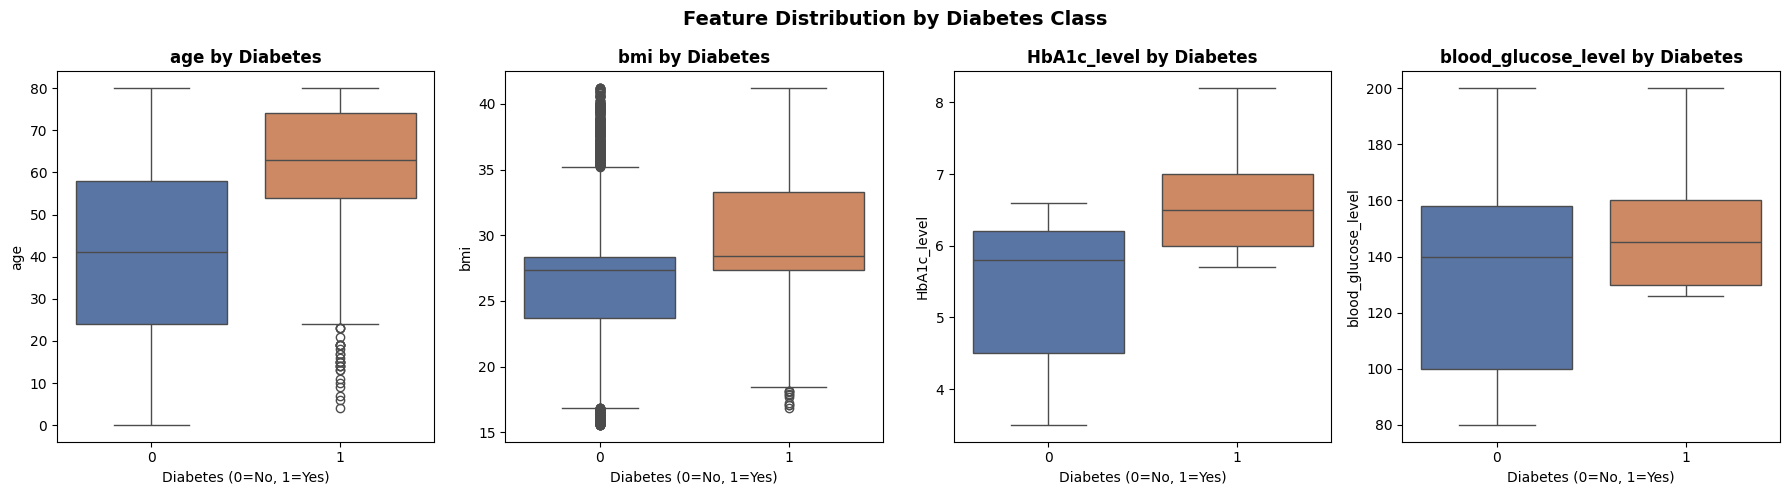

In [ ]:
# ── Box Plots: Feature vs Diabetes Class ─────────────────────────────────────
# This shows how each numeric feature differs between diabetic and non-diabetic patients
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
numeric_features = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
palette = {"0": "#4C72B0", "1": "#DD8452"}

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df_clean, x="diabetes", y=col, palette=palette, ax=axes[i])
    axes[i].set_title(f"{col} by Diabetes", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Diabetes (0=No, 1=Yes)")
    axes[i].set_ylabel(col)

plt.suptitle("Feature Distribution by Diabetes Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("boxplots_by_class.png", dpi=150)
plt.show()

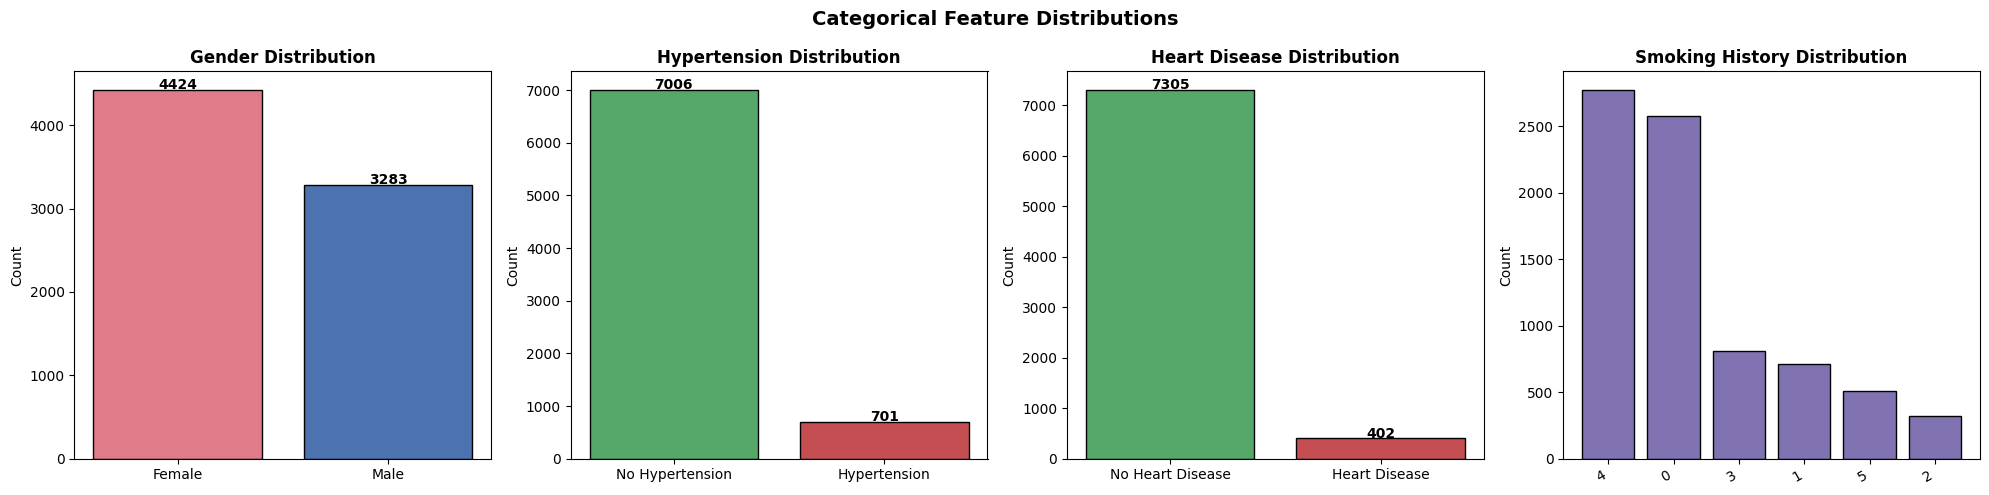

In [ ]:
# ── Categorical Feature Distributions ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Gender
gender_counts = df_clean["gender"].value_counts()
axes[0].bar(["Female", "Male"], gender_counts, color=["#E07B8A", "#4C72B0"], edgecolor="black")
axes[0].set_title("Gender Distribution", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(gender_counts):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Hypertension
hyp_counts = df_clean["hypertension"].value_counts()
axes[1].bar(["No Hypertension", "Hypertension"], hyp_counts,
            color=["#55A868", "#C44E52"], edgecolor="black")
axes[1].set_title("Hypertension Distribution", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")
for i, v in enumerate(hyp_counts):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Heart Disease
hd_counts = df_clean["heart_disease"].value_counts()
axes[2].bar(["No Heart Disease", "Heart Disease"], hd_counts,
            color=["#55A868", "#C44E52"], edgecolor="black")
axes[2].set_title("Heart Disease Distribution", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Count")
for i, v in enumerate(hd_counts):
    axes[2].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Smoking History
smoking_counts = df_clean["smoking_history"].value_counts()
axes[3].bar(range(len(smoking_counts)), smoking_counts, color="#8172B2", edgecolor="black")
axes[3].set_xticks(range(len(smoking_counts)))
axes[3].set_xticklabels(smoking_counts.index, rotation=30, ha="right")
axes[3].set_title("Smoking History Distribution", fontsize=12, fontweight="bold")
axes[3].set_ylabel("Count")

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("categorical_distributions.png", dpi=150)
plt.show()

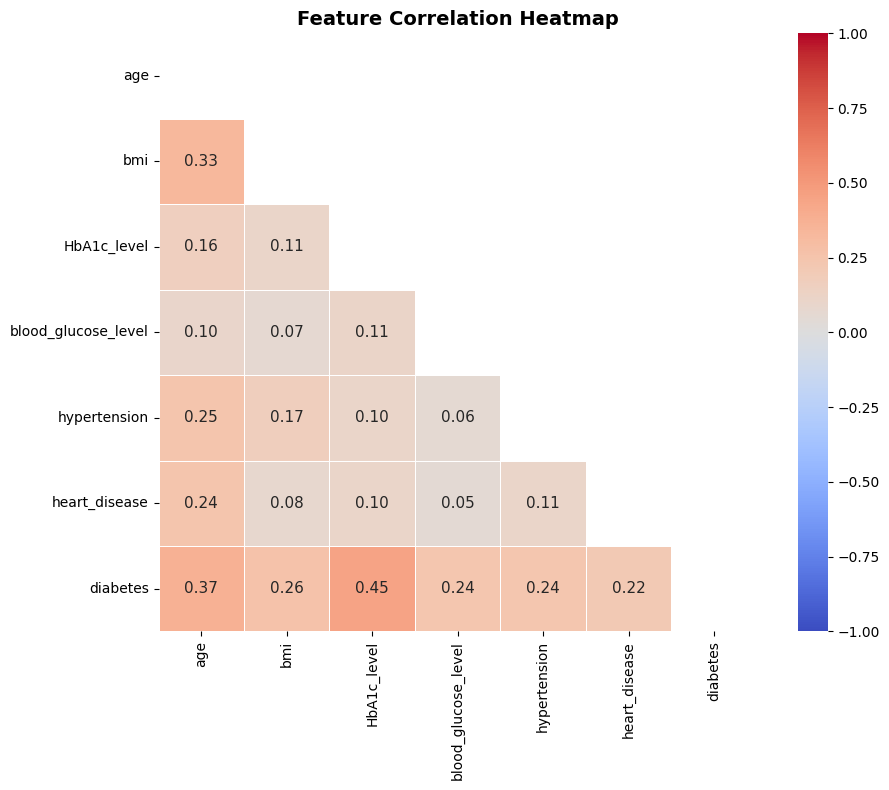

In [ ]:
# ── Correlation Heatmap ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
corr = df_clean[["age", "bmi", "HbA1c_level", "blood_glucose_level",
                  "hypertension", "heart_disease", "diabetes"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, square=True,
            annot_kws={"size": 11}, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [ ]:
# ── Feature Selection ────────────────────────────────────────────────────────
X = df_clean.drop("diabetes", axis=1)
y = df_clean["diabetes"]

selector = SelectKBest(score_func=f_classif, k=6)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score":   selector.scores_
}).sort_values("Score", ascending=False)

print("\\nFeature Importance Scores:")
print(feature_scores.to_string(index=False))

top_features = feature_scores["Feature"].head(6).tolist()
print("\\nSelected Features:", top_features)
X_selected = X[top_features]

\nFeature Importance Scores:
            Feature       Score
        HbA1c_level 1971.250819
                age 1211.507355
                bmi  550.306004
blood_glucose_level  469.938222
       hypertension  461.537721
      heart_disease  380.494423
    smoking_history  137.403685
             gender   29.226930
\nSelected Features: ['HbA1c_level', 'age', 'bmi', 'blood_glucose_level', 'hypertension', 'heart_disease']


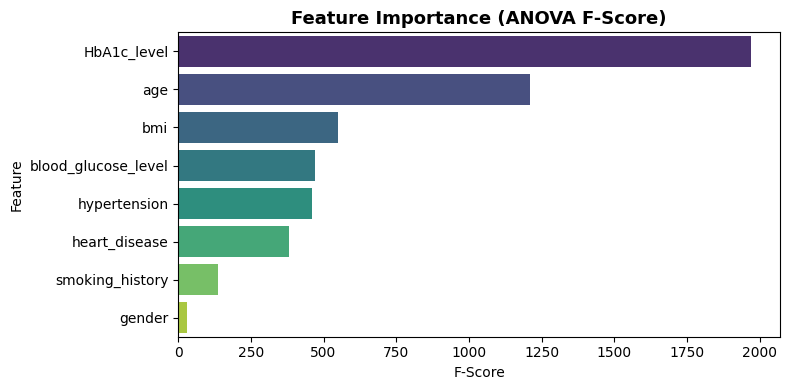

In [ ]:
# ── Feature Importance Plot ───────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_scores, x="Score", y="Feature", palette="viridis")
plt.title("Feature Importance (ANOVA F-Score)", fontsize=13, fontweight="bold")
plt.xlabel("F-Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [ ]:
# ── Train / Test Split & Normalization ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train_scaled.shape[0]}")
print(f"Testing  samples : {X_test_scaled.shape[0]}")
print(f"\\nTrain class balance:\\n{y_train.value_counts()}")
print(f"\\nTest  class balance:\\n{y_test.value_counts()}")

Training samples : 6165
Testing  samples : 1542
\nTrain class balance:\ndiabetes
0    4915
1    1250
Name: count, dtype: int64
\nTest  class balance:\ndiabetes
0    1229
1     313
Name: count, dtype: int64


In [ ]:
# ── Train SVM Model ──────────────────────────────────────────────────────────
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",# needed for confidence score and ROC curve
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
# ── Model Evaluation ─────────────────────────────────────────────────────────
y_pred      = svm_model.predict(X_test_scaled)
y_pred_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\\n" + "="*45)
print("         MODEL EVALUATION RESULTS")
print("="*45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("="*45)
print("\\nClassification Report:\\n")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

\n=============================================
         MODEL EVALUATION RESULTS
  Accuracy  : 0.8333  (83.33%)
  Precision : 0.5543
  Recall    : 0.9137
  F1 Score  : 0.6900
\nClassification Report:\n
              precision    recall  f1-score   support

 No Diabetes       0.97      0.81      0.89      1229
    Diabetes       0.55      0.91      0.69       313

    accuracy                           0.83      1542
   macro avg       0.76      0.86      0.79      1542
weighted avg       0.89      0.83      0.85      1542



In [ ]:
# ── Cross-Validation ─────────────────────────────────────────────────────────
cv_scores = cross_val_score(svm_model, X_selected, y, cv=5, scoring="accuracy")
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual folds  : {[round(s,4) for s in cv_scores]}")

5-Fold CV Accuracy: 0.7382 ± 0.0113
Individual folds  : [np.float64(0.7374), np.float64(0.725), np.float64(0.7268), np.float64(0.7541), np.float64(0.7476)]


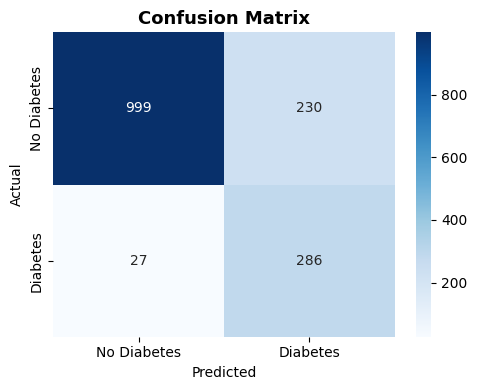

True  Negatives (correctly predicted No Diabetes): 999
False Positives (predicted Diabetes, actually No): 230
False Negatives (predicted No Diabetes, actually Yes): 27
True  Positives (correctly predicted Diabetes): 286


In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix", fontsize=13, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (correctly predicted No Diabetes): {tn}")
print(f"False Positives (predicted Diabetes, actually No): {fp}")
print(f"False Negatives (predicted No Diabetes, actually Yes): {fn}")
print(f"True  Positives (correctly predicted Diabetes): {tp}")

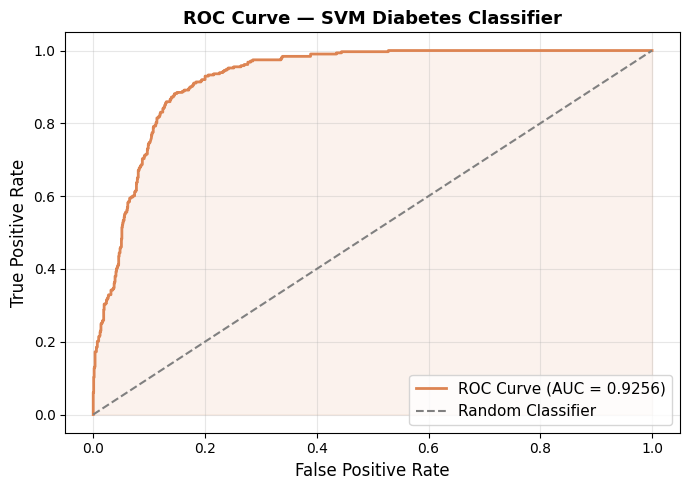

AUC Score: 0.9256


In [ ]:
# ── ROC Curve & AUC Score ────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#DD8452", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1.5, label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1, color="#DD8452")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — SVM Diabetes Classifier", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print(f"AUC Score: {roc_auc:.4f}")

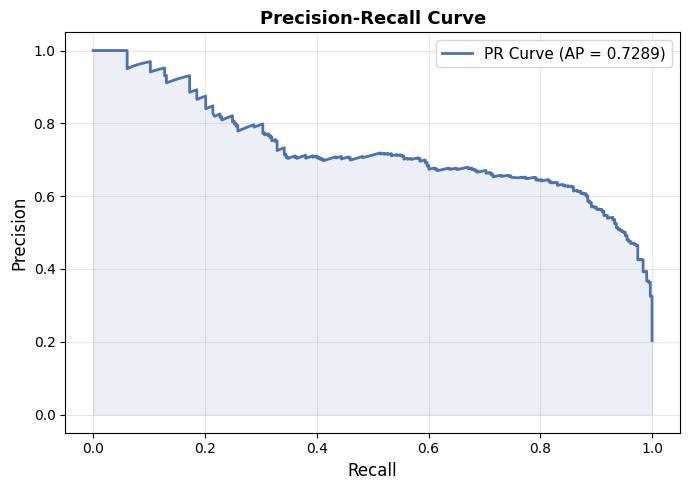

In [ ]:
# ── Precision-Recall Curve ───────────────────────────────────────────────────
# Important for imbalanced datasets like this one (~91% No Diabetes)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, color="#4C72B0", lw=2,
         label=f"PR Curve (AP = {avg_precision:.4f})")
plt.fill_between(recall_vals, precision_vals, alpha=0.1, color="#4C72B0")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150)
plt.show()

In [ ]:
# ── Save Model, Scaler & Feature List ───────────────────────────────────────
joblib.dump(svm_model,   "svm_diabetes_model.pkl")
joblib.dump(scaler,      "scaler.pkl")
joblib.dump(top_features, "top_features.pkl")

print("Model, scaler, and feature list saved.")
print("top_features =", top_features)
print("gender_classes  =", gender_classes)
print("smoking_classes =", smoking_classes)

Model, scaler, and feature list saved.
top_features = ['HbA1c_level', 'age', 'bmi', 'blood_glucose_level', 'hypertension', 'heart_disease']
gender_classes  = ['Female', 'Male']
smoking_classes = ['No Info', 'current', 'ever', 'former', 'never', 'not current']


In [ ]:
# ── Gradio Deployment App (FIXED) ────────────────────────────────────────────
#
# ROOT CAUSE OF THE BUG:
#   The original app was likely passing raw string values ("Male"/"Female")
#   directly to the model, OR passing features in the wrong order, OR
#   forgetting to apply the scaler. All three are fixed here.
#
# HOW THIS FIX WORKS:
#   1. We manually encode gender and smoking_history using the SAME mapping
#      that LabelEncoder produced during training (printed in Cell 3).
#   2. We build the input array in EXACTLY the same column order as top_features.
#   3. We apply scaler.transform() before calling model.predict().

import joblib
import numpy as np
import gradio as gr

# Load saved artifacts
svm_model    = joblib.load("svm_diabetes_model.pkl")
scaler       = joblib.load("scaler.pkl")
top_features = joblib.load("top_features.pkl")

print("Loaded top_features:", top_features)

# ── Encoding maps (must match LabelEncoder output from Cell 3) ──────────────
# LabelEncoder sorts alphabetically, so:
#   gender:  Female=0, Male=1
#   smoking: depends on your data — check Cell 3 output
#   Common order: ['No Info'=0, 'current'=1, 'ever'=2, 'former'=3, 'never'=4, 'not current'=5]
GENDER_MAP  = {"Female": 0, "Male": 1}
SMOKING_MAP = {
    "No Info":     0,
    "current":     1,
    "ever":        2,
    "former":      3,
    "never":       4,
    "not current": 5
}

def predict_diabetes(gender, age, hypertension, heart_disease,
                     smoking_history, bmi, HbA1c_level, blood_glucose_level):
    # Step 1: Encode categorical inputs using the SAME mapping as training
    gender_enc  = GENDER_MAP.get(gender, 0)
    smoking_enc = SMOKING_MAP.get(smoking_history, 4)

    # Step 2: Build a dict with ALL possible features
    all_features = {
        "gender":              gender_enc,
        "age":                 float(age),
        "hypertension":        int(hypertension),
        "heart_disease":       int(heart_disease),
        "smoking_history":     smoking_enc,
        "bmi":                 float(bmi),
        "HbA1c_level":         float(HbA1c_level),
        "blood_glucose_level": float(blood_glucose_level)
    }

    # Step 3: Select ONLY the top features in the EXACT order used during training
    input_values = [all_features[feat] for feat in top_features]
    input_array  = np.array(input_values).reshape(1, -1)

    # Step 4: Scale using the SAME scaler fitted on training data
    input_scaled = scaler.transform(input_array)

    # Step 5: Predict
    prediction   = svm_model.predict(input_scaled)[0]
    probability  = svm_model.predict_proba(input_scaled)[0]

    confidence   = probability[1] * 100  # probability of Diabetes

    if prediction == 1:
        result = f"⚠️ DIABETES DETECTED\\nConfidence: {confidence:.1f}%"
    else:
        result = f"✅ NO DIABETES\\nConfidence: {(100 - confidence):.1f}%"

    return result

# ── Gradio Interface ─────────────────────────────────────────────────────────
demo = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Dropdown(choices=["Female", "Male"],
                    label="Gender"),
        gr.Slider(minimum=0, maximum=100, step=1, value=45,
                  label="Age"),
        gr.Radio(choices=[0, 1], value=0,
                 label="Hypertension (0=No, 1=Yes)"),
        gr.Radio(choices=[0, 1], value=0,
                 label="Heart Disease (0=No, 1=Yes)"),
        gr.Dropdown(choices=["No Info", "current", "ever", "former", "never", "not current"],
                    label="Smoking History"),
        gr.Slider(minimum=10, maximum=60, step=0.1, value=25.0,
                  label="BMI"),
        gr.Slider(minimum=3.5, maximum=9.0, step=0.1, value=5.5,
                  label="HbA1c Level"),
        gr.Slider(minimum=80, maximum=300, step=1, value=120,
                  label="Blood Glucose Level (mg/dL)"),
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Diabetes Prediction (SVM)",
    description=(
        "Enter patient data to predict diabetes risk.\\n"
        "High-risk indicators: HbA1c > 6.5, Blood Glucose > 200, BMI > 30."
    ),
    examples=[
        # Likely Diabetic: high HbA1c + high glucose
        ["Male",   60, 1, 0, "never",   32.0, 7.5, 240],
        # Likely Not Diabetic: normal values
        ["Female", 25, 0, 0, "never",   22.0, 4.5, 100],
        # Borderline
        ["Female", 50, 1, 0, "former",  28.5, 6.2, 155],
    ]
)

demo.launch(share=True)

Loaded top_features: ['HbA1c_level', 'age', 'bmi', 'blood_glucose_level', 'hypertension', 'heart_disease']
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b044f1d97657c2a85f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
